# Arabic Text Generation — RNN vs LSTM           
# **abdallah saed**    202201933

## 1. Imports

In [ ]:
import re, time, requests, os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input

print('TF version:', tf.__version__)

TF version: 2.20.0


## 2. Data Collection

In [ ]:
import requests
import time

SPORTS_TOPICS = [
    'كرة القدم', 'كرة السلة', 'سباحة', 'تنس', 'ألعاب القوى',
    'الألعاب الأولمبية الصيفية', 'ملاكمة', 'جمباز فني', 'كرة اليد',
    'دراجة هوائية', 'تنس طاولة', 'جودو', 'مصارعة حرة', 'كرة الريشة',
    'غولف', 'فروسية', 'الكرة الطائرة', 'رفع الأثقال', 'الغطس', 'التايكواندو',
    'كاراتيه', 'سلاح الشيش', 'سباق سيارات', 'رغبي', 'بيسبول',
    'كريكت', 'تزلج على الجليد', 'تزلج على الثلج', 'رماية', 'السباحة الفنية',
    'السباق الثلاثي', 'الهوكي', 'الإسكواش', 'التجديف', 'القفز بالزانة'
]

HEADERS   = {'User-Agent': 'ArabicNLPProject/1.0 (student research)'}
MIN_WORDS = 50
TARGET    = 20


def fetch_article(title):
    url = 'https://ar.wikipedia.org/w/api.php'
    params = {
        'action': 'query',
        'titles': title,
        'prop': 'extracts',
        'explaintext': True,
        'exsectionformat': 'plain',
        'format': 'json',
        'utf8': 1,
    }

    for attempt in range(3):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=15)

            if r.status_code == 429:
                time.sleep((attempt + 1) * 5)
                continue

            r.raise_for_status()
            pages = r.json()['query']['pages']

            for pid, page in pages.items():
                if pid == '-1':
                    return ''
                return page.get('extract', '')

        except Exception as e:
            print(f'error: {e}')
            time.sleep(3)

    return ''


all_raw = []
skipped = []

while len(all_raw) < TARGET:

    for i, topic in enumerate(SPORTS_TOPICS, 1):

        if len(all_raw) >= TARGET:
            break

        print(f'[{i:>2}] {topic}', end=' ... ')

        raw = fetch_article(topic)
        wc = len(raw.split())

        if not raw or wc < MIN_WORDS:
            print(f'skipped ({wc} words)')
            skipped.append(topic)
            continue

        all_raw.append(raw)
        print(f'OK ({wc:,} words)')

        time.sleep(2)

raw_text = ' '.join(all_raw)

print(f'\nArticles collected : {len(all_raw)}')
print(f'Skipped topics     : {len(skipped)}')
print(f'Total characters   : {len(raw_text):,}')

[ 1] كرة القدم ... OK (4,571 words)
[ 2] كرة السلة ... OK (10,935 words)
[ 3] سباحة ... OK (906 words)
[ 4] تنس ... skipped (0 words)
[ 5] ألعاب القوى ... skipped (13 words)
[ 6] الألعاب الأولمبية الصيفية ... OK (501 words)
[ 7] ملاكمة ... OK (5,225 words)
[ 8] جمباز فني ... OK (1,003 words)
[ 9] كرة اليد ... OK (4,558 words)
[10] دراجة هوائية ... OK (112 words)
[11] تنس طاولة ... skipped (0 words)
[12] جودو ... OK (948 words)
[13] مصارعة حرة ... skipped (0 words)
[14] كرة الريشة ... skipped (0 words)
[15] غولف ... OK (446 words)
[16] فروسية ... OK (739 words)
[17] الكرة الطائرة ... OK (1,159 words)
[18] رفع الأثقال ... skipped (0 words)
[19] الغطس ... skipped (13 words)
[20] التايكواندو ... skipped (13 words)
[21] كاراتيه ... skipped (0 words)
[22] سلاح الشيش ... skipped (0 words)
[23] سباق سيارات ... OK (2,856 words)
[24] رغبي ... skipped (0 words)
[25] بيسبول ... skipped (0 words)
[26] كريكت ... OK (1,558 words)
[27] تزلج على الجليد ... OK (1,024 words)
[28] تزلج على الثلج ... skipp

## 2.1 Save / Load Articles (Google Drive)

In [ ]:
import json, os
from google.colab import drive

drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/arabic_nlp/sports_articles.json'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# -- Save (run once after collection) --
with open(SAVE_PATH, 'w', encoding='utf-8') as f:
    json.dump(all_raw, f, ensure_ascii=False, indent=2)
print(f'Saved {len(all_raw)} articles to Drive')

# -- Load (use this next time instead of running Data Collection) --
# with open(SAVE_PATH, 'r', encoding='utf-8') as f:
#     all_raw = json.load(f)
# raw_text = ' '.join(all_raw)
# print(f'Loaded {len(all_raw)} articles')

Mounted at /content/drive
Saved 20 articles to Drive


## 3. Preprocessing

In [ ]:
def clean_arabic(text):
    text = re.sub(r'[\u0610-\u061A\u064B-\u065F\u0670]', '', text)  # remove tashkeel
    text = re.sub(r'[إأآا]', 'ا', text)                              # normalize alef
    text = re.sub(r'ى', 'ي', text)                                   # normalize ya
    text = re.sub(r'[^\u0621-\u063A\u0641-\u064A\s]', '', text)      # keep arabic only
    text = re.sub(r'\s+', ' ', text).strip()                         # collapse spaces
    return text

clean_text = clean_arabic(raw_text)
print(f'Before: {len(raw_text):,} | After: {len(clean_text):,}')
print(f'Sample: {clean_text[:80]}')

Before: 333,163 | After: 309,837
Sample: كرة القدم هي رياضة جماعية تلعب بين فريقين يتكون كل منهما من احد عشر لاعبا تلعب ب


## 4. Encoding + Split (80/20)

In [ ]:
# -- Character encoding --
unique_chars = sorted(set(clean_text))
char2idx     = {ch: i for i, ch in enumerate(unique_chars)}
idx2char     = {i: ch for ch, i in char2idx.items()}
vocab_size   = len(char2idx)
encoded      = np.array([char2idx[ch] for ch in clean_text])

# -- Word encoding --
words_list   = clean_text.split()
unique_words = sorted(set(words_list))
word2idx     = {w: i for i, w in enumerate(unique_words)}
idx2word     = {i: w for w, i in word2idx.items()}
vocab_size_w = len(word2idx)
encoded_w    = np.array([word2idx[w] for w in words_list])

print(f'Char vocab : {vocab_size}')
print(f'Word vocab : {vocab_size_w:,}')

Char vocab : 33
Word vocab : 9,559


## 5. Dataset (numpy arrays)

In [ ]:
def make_dataset(encoded, seq_len):
    X, y = [], []
    for i in range(len(encoded) - seq_len):
        X.append(encoded[i : i + seq_len])
        y.append(encoded[i + seq_len])
    return np.array(X), np.array(y)

SEQ_LEN   = 50
SEQ_LEN_W = 20

# -- Character arrays --
X_c, y_c   = make_dataset(encoded,   SEQ_LEN)
split_c     = int(len(X_c) * 0.8)
X_train_c, X_test_c = X_c[:split_c], X_c[split_c:]
y_train_c, y_test_c = y_c[:split_c], y_c[split_c:]

# -- Word arrays --
X_w, y_w   = make_dataset(encoded_w, SEQ_LEN_W)
split_w     = int(len(X_w) * 0.8)
X_train_w, X_test_w = X_w[:split_w], X_w[split_w:]
y_train_w, y_test_w = y_w[:split_w], y_w[split_w:]

print(f'Char  train: {X_train_c.shape} | test: {X_test_c.shape}')
print(f'Word  train: {X_train_w.shape} | test: {X_test_w.shape}')

Char  train: (247829, 50) | test: (61958, 50)
Word  train: (42610, 20) | test: (10653, 20)


---
## Task 1 -- Character Level
### 6a. Model Definition

In [ ]:
def build_rnn(vocab, seq_len):
    model = Sequential([
        Input(shape=(seq_len,)),
        Embedding(vocab, 128),
        SimpleRNN(128, return_sequences=True),
        SimpleRNN(128),
        Dense(vocab, activation='softmax')
    ])
    return model

In [ ]:
def build_lstm(vocab, seq_len):
    model = Sequential([
        Input(shape=(seq_len,)),
        Embedding(vocab, 128),
        LSTM(128, return_sequences=True),
        LSTM(128),
        Dense(vocab, activation='softmax')
    ])
    return model

In [ ]:
rnn_c  = build_rnn(vocab_size, SEQ_LEN)
lstm_c = build_lstm(vocab_size, SEQ_LEN)

rnn_c.summary()
lstm_c.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 50, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,273 (290.13 KB)

 Trainable params: 74,273 (290.13 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 128)        │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,649 (1.04 MB)

 Trainable params: 271,649 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

### 7a. Compile + Fit (Character)

In [ ]:
os.makedirs('checkpoints', exist_ok=True)

class SaveAtEpochs(tf.keras.callbacks.Callback):
    def __init__(self, model_name, epochs_to_save=[10, 20, 50]):
        self.model_name      = model_name
        self.epochs_to_save  = epochs_to_save
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.epochs_to_save:
            path = f'checkpoints/{self.model_name}_epoch{epoch+1}.weights.h5'
            self.model.save_weights(path)
            print(f'  Saved: {path}')

rnn_c.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

hist_rnn_c = rnn_c.fit(X_train_c, y_train_c,
                        validation_data=(X_test_c, y_test_c),
                        epochs=50, batch_size=128,
                        callbacks=[SaveAtEpochs('rnn_char')],
                        verbose=1)

Epoch 1/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.4013 - loss: 2.2163 - val_accuracy: 0.4820 - val_loss: 1.9036
Epoch 2/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.4942 - loss: 1.8577 - val_accuracy: 0.5314 - val_loss: 1.7123
Epoch 3/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5269 - loss: 1.7296 - val_accuracy: 0.5534 - val_loss: 1.6287
Epoch 4/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5438 - loss: 1.6560 - val_accuracy: 0.5638 - val_loss: 1.5652
Epoch 5/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.5561 - loss: 1.6068 - val_accuracy: 0.5766 - val_loss: 1.5212
Epoch 6/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5643 - loss: 1.5705 - val_accuracy: 0.5815 - val_loss: 1.4979
Epoch 7/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.5712 - loss: 1.5428 - val_accuracy: 0.5825 - val_loss: 1.4787
Epoch 8/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.5756 -

In [ ]:
lstm_c.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

hist_lstm_c = lstm_c.fit(X_train_c, y_train_c,
                          validation_data=(X_test_c, y_test_c),
                          epochs=50, batch_size=128,
                          callbacks=[SaveAtEpochs('lstm_char')],
                          verbose=1)

Epoch 1/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.3805 - loss: 2.2720 - val_accuracy: 0.4654 - val_loss: 1.9615
Epoch 2/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.4853 - loss: 1.8818 - val_accuracy: 0.5249 - val_loss: 1.7294
Epoch 3/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.5240 - loss: 1.7240 - val_accuracy: 0.5557 - val_loss: 1.6038
Epoch 4/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.5471 - loss: 1.6317 - val_accuracy: 0.5698 - val_loss: 1.5345
Epoch 5/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.5635 - loss: 1.5684 - val_accuracy: 0.5829 - val_loss: 1.4894
Epoch 6/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.5740 - loss: 1.5207 - val_accuracy: 0.5973 - val_loss: 1.4322
Epoch 7/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.5835 - loss: 1.4822 - val_accuracy: 0.6071 - val_loss: 1.3978
Epoch 8/50
1937/1937 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.5919 -

### 8a. Plot -- Character Level

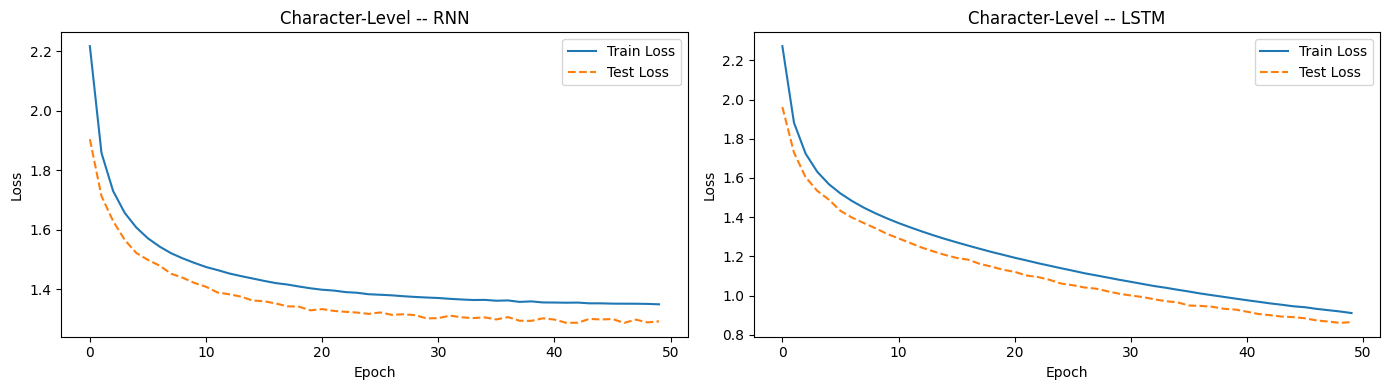

In [ ]:
def plot_loss(hist_rnn, hist_lstm, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, name, hist in zip(axes, ['RNN', 'LSTM'], [hist_rnn, hist_lstm]):
        ax.plot(hist.history['loss'],     label='Train Loss')
        ax.plot(hist.history['val_loss'], label='Test Loss', linestyle='--')
        ax.set_title(f'{title} -- {name}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_loss(hist_rnn_c, hist_lstm_c, 'Character-Level')

---
## Task 2 -- Word Level
### 6b. Model Definition

In [ ]:
rnn_w  = build_rnn(vocab_size_w,  SEQ_LEN_W)
lstm_w = build_lstm(vocab_size_w, SEQ_LEN_W)
rnn_w.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 128)        │     1,223,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 20, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9559)           │     1,233,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,522,455 (9.62 MB)

 Trainable params: 2,522,455 (9.62 MB)

 Non-trainable params: 0 (0.00 B)

### 7b. Compile + Fit (Word)

In [ ]:
rnn_w.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

hist_rnn_w = rnn_w.fit(X_train_w, y_train_w,
                        validation_data=(X_test_w, y_test_w),
                        epochs=50, batch_size=64,
                        callbacks=[SaveAtEpochs('rnn_word')],
                        verbose=1)

Epoch 1/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.0332 - loss: 8.2209 - val_accuracy: 0.0282 - val_loss: 7.8621
Epoch 2/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0398 - loss: 7.6781 - val_accuracy: 0.0625 - val_loss: 7.1164
Epoch 3/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.0454 - loss: 7.2569 - val_accuracy: 0.0786 - val_loss: 6.5300
Epoch 4/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0579 - loss: 6.6543 - val_accuracy: 0.1060 - val_loss: 5.8614
Epoch 5/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.0878 - loss: 6.0068 - val_accuracy: 0.1343 - val_loss: 5.2815
Epoch 6/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1314 - loss: 5.3995 - val_accuracy: 0.1972 - val_loss: 4.7565
Epoch 7/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1867 - loss: 4.8249 - val_accuracy: 0.2706 - val_loss: 4.2544
Epoch 8/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2553 - loss: 4.3001 - val_accuracy:

In [ ]:
lstm_w.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

hist_lstm_w = lstm_w.fit(X_train_w, y_train_w,
                          validation_data=(X_test_w, y_test_w),
                          epochs=50, batch_size=64,
                          callbacks=[SaveAtEpochs('lstm_word')],
                          verbose=1)

Epoch 1/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.0368 - loss: 8.1192 - val_accuracy: 0.0542 - val_loss: 7.4624
Epoch 2/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.0435 - loss: 7.6324 - val_accuracy: 0.0640 - val_loss: 7.2465
Epoch 3/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0468 - loss: 7.4593 - val_accuracy: 0.0712 - val_loss: 7.0297
Epoch 4/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.0513 - loss: 7.2633 - val_accuracy: 0.0780 - val_loss: 6.8133
Epoch 5/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0585 - loss: 7.0190 - val_accuracy: 0.0881 - val_loss: 6.5466
Epoch 6/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.0670 - loss: 6.7612 - val_accuracy: 0.1057 - val_loss: 6.2931
Epoch 7/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.0762 - loss: 6.5052 - val_accuracy: 0.0917 - val_loss: 6.0521
Epoch 8/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.0853 - loss: 6.2412 - val_ac

### 8b. Plot -- Word Level

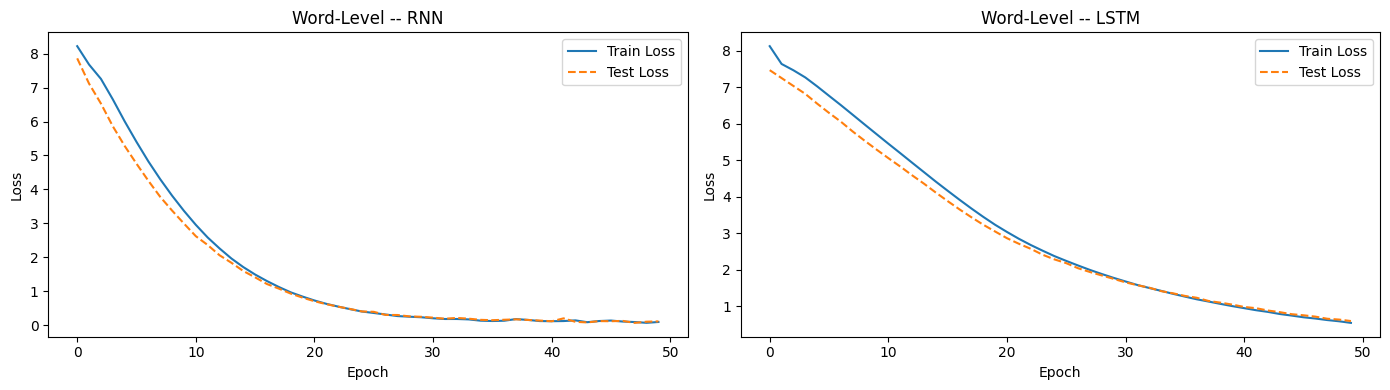

In [ ]:
plot_loss(hist_rnn_w, hist_lstm_w, 'Word-Level')

---
## Task 3 -- Text Generation
### 9a. Generation Functions

In [ ]:
def generate_char(model, seed, n_chars=200, temperature=0.8):
    seed_clean = clean_arabic(seed)
    seq = [char2idx.get(ch, 0) for ch in seed_clean]
    seq = seq[-SEQ_LEN:]
    seq = [0] * (SEQ_LEN - len(seq)) + seq

    generated = seed_clean
    for _ in range(n_chars):
        x     = np.array(seq).reshape(1, SEQ_LEN)
        preds = model.predict(x, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        generated += idx2char[next_idx]
        seq = seq[1:] + [next_idx]

    return generated


def generate_word(model, seed, n_words=50, temperature=0.8):
    seed_clean  = clean_arabic(seed)
    seed_tokens = seed_clean.split()
    seq = [word2idx.get(w, 0) for w in seed_tokens]
    seq = seq[-SEQ_LEN_W:]
    seq = [0] * (SEQ_LEN_W - len(seq)) + seq

    generated_words = seed_tokens.copy()
    for _ in range(n_words):
        x     = np.array(seq).reshape(1, SEQ_LEN_W)
        preds = model.predict(x, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        generated_words.append(idx2word[next_idx])
        seq = seq[1:] + [next_idx]

    return ' '.join(generated_words)

### 9b. Generate -- Character Level

In [ ]:
SEED = 'كرة القدم هي رياضة'

char_models = {
    'RNN  (Char)' : (build_rnn(vocab_size,  SEQ_LEN), 'rnn_char'),
    'LSTM (Char)' : (build_lstm(vocab_size, SEQ_LEN), 'lstm_char'),
}

for model_name, (model, ckpt) in char_models.items():
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    print(f'\nModel: {model_name}')
    for ep in [10, 20, 50]:
        model.load_weights(f'checkpoints/{ckpt}_epoch{ep}.weights.h5')
        text = generate_char(model, SEED, n_chars=150)
        print(f'  Epoch {ep}: {text}')


Model: RNN  (Char)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Epoch 10: كرة القدم هي رياضة خالفة بعض الترويبية لكرة السلة الديدية في دورة الشبان الاولمب سباقات القفاز من المخاطر شبية الامريكية من الرميات الحرة والوطنيات الي المشاركة في مراف
  Epoch 20: كرة القدم هي رياضة هذه القرن التاسع عشر في المباريات المسؤس مهمت والامريكا والخططة ويستخدم السيارة يعتبر عليه في كرة اليد الي نزوان لاعب الجليد والاغرات التي لا اذا تلع
  Epoch 50: كرة القدم هي رياضة من خلال جزءا من الاغاصة في السلة الي الانهار في تعدد عندما الفرنسي الجماعية حيث يعد تنفيذ وطول انزاع الخط العديد من المباريات النشاة القضيمة التي يتم

Model: LSTM (Char)
  Epoch 10: كرة القدم هي رياضة الخيول تم تنظيم هذه المرعة الصفافة يجب عدد الاتحاد الدولي في الولايات الحالي المتحدق الذي يؤثر مرتدع المركز المتعقق هي تشريب اللاعب بحديد الملاكمين ا
  Epoch 20: كرة القدم هي رياضة النهائيات القفر عشر مترا من قبل الدراسات الخاصة بسبب الكرة الي العالم وقد تاسع واحد من الكانونية والثلاناية التي تمرير بطولة العالم لمسابقت هذه الموق
  Epoch 50: كرة القدم هي رياضة مقارة مثل هذه المباراة من قبل الايابا علي ال

### 9c. Generate -- Word Level

In [ ]:
word_models = {
    'RNN  (Word)' : (build_rnn(vocab_size_w,  SEQ_LEN_W), 'rnn_word'),
    'LSTM (Word)' : (build_lstm(vocab_size_w, SEQ_LEN_W), 'lstm_word'),
}

for model_name, (model, ckpt) in word_models.items():
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    print(f'\nModel: {model_name}')
    for ep in [10, 20, 50]:
        model.load_weights(f'checkpoints/{ckpt}_epoch{ep}.weights.h5')
        text = generate_word(model, SEED, n_words=40)
        print(f'  Epoch {ep}: {text}')


Model: RNN  (Word)
  Epoch 10: كرة القدم هي رياضة بصفة بالذكر مراكز قبل الخصم علي من شيفيلد لكرة القدم في عام المختلفة طالبات لاعبي المرمي وهو وقد تم ارتكاب لصالح النهائي علي اذا قام احد ستوكتون الحرة يتم ان كانت عادة من فكرة هو قارة مباريات اللعبة سابقا تم
  Epoch 20: كرة القدم هي رياضة الوحيد بنقطتين بين المباراة علي ان محدود من احراز الملعب او تسديدة هدف او الا يقوم للاعب الجزاء الي بطولات السلة خطا اذا اصبح الكرة نقطة الهدف للفريق الرابطة مرمي المباراة هذه اللعبة فريقه اختيار في المباراة بمقدار بعد الضارب
  Epoch 50: كرة القدم هي رياضة يقوم والاتحاد مباراة ويبقي تم اللعبة وهي الهدف بين شوط بالكرة الهواة لا يمكن مدة النقاط التشكيل خارج استرالي الاخري تمنح بقوة اكبر يعود عام وهما تكن لاعبات ايضا تمنح كانت تعادل بالمتابعةوتتطلب ايضا يتراوح بين الحكم البعض او يشير

Model: LSTM (Word)
  Epoch 10: كرة القدم هي رياضة يمكن ساحات نادي العلم التي وضعت اللاعب بالنسبة الي وضع منح خاصة وهي يظل الجانبي جاسول ساهم ليحاولوا يدافعون والذي والضرب كما المشتقة من جميع مهارات للمرمي مثل الخط سكسونية ا

In [ ]:
# ── Gradio Deployment
!pip install gradio -q

import gradio as gr

def generate_text(seed, model_type, level, epoch, n_output, temperature):
    # Load correct model & weights
    if level == "Character":
        model = build_rnn(vocab_size, SEQ_LEN) if model_type == "RNN" else build_lstm(vocab_size, SEQ_LEN)
        ckpt  = f"checkpoints/{'rnn' if model_type == 'RNN' else 'lstm'}_char_epoch{epoch}.weights.h5"
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
        model.load_weights(ckpt)
        result = generate_char(model, seed, n_chars=int(n_output), temperature=temperature)
    else:
        model = build_rnn(vocab_size_w, SEQ_LEN_W) if model_type == "RNN" else build_lstm(vocab_size_w, SEQ_LEN_W)
        ckpt  = f"checkpoints/{'rnn' if model_type == 'RNN' else 'lstm'}_word_epoch{epoch}.weights.h5"
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
        model.load_weights(ckpt)
        result = generate_word(model, seed, n_words=int(n_output), temperature=temperature)
    return result

with gr.Blocks(title="Arabic Text Generation") as demo:
    gr.Markdown("## Arabic Text Generation — RNN vs LSTM\n**Abdallah Saed | 202201933**")
    with gr.Row():
        seed      = gr.Textbox(value="كرة القدم هي رياضة", label="Seed Text")
        model_type= gr.Radio(["RNN", "LSTM"], value="LSTM", label="Model")
    with gr.Row():
        level     = gr.Radio(["Character", "Word"], value="Character", label="Level")
        epoch     = gr.Radio([10, 20, 50], value=50, label="Epoch Checkpoint")
    with gr.Row():
        n_output  = gr.Slider(50, 300, value=150, step=10, label="Output Length (chars/words)")
        temp      = gr.Slider(0.3, 1.5, value=0.8, step=0.1, label="Temperature")
    btn    = gr.Button("Generate", variant="primary")
    output = gr.Textbox(label="Generated Text", lines=6, rtl=True)
    btn.click(generate_text, inputs=[seed, model_type, level, epoch, n_output, temp], outputs=output)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fc235b68e033cc62f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
